# **Text Classification of Hotel Review Using Simple RNN, LSTM and Word2Vec Model**

### Introduction
This notebook focuses on classifying hotel reviews into star ratings ranging from 1 to 5, using their textual descriptions as input. Our goal is to predict rating based on input description and compare the effectiveness of three different neural network architectures (Simple RNN, LSTM, Word2Vec) for natural language processing following the below steps:

1. Data Preprocessing & Cleaning
2. Tokenization & Padding
3. Model Building
4. Training & Evaluation
5. Visualization
6. GUI Implementation for Real-Time Prediction

## **Imports & Setup**

In [1]:
!pip install contractions gensim pandas tensorflow wget wordcloud

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 9.3 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=a9c8573d52d028aae2adcb167b9330b50c883825fb9dbc244e0f2d8f1a3ae65f
  Stored in directory: /root/.cache/pip/wheels/40/b3/0f/a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built wget
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uni

## 1. **Data Preprocessing & Cleaning**

First, let's import the necessary libraries and load the dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils import class_weight
from wordcloud import WordCloud
import contractions
import random
from nltk.corpus import wordnet


# Download nltk resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
# Load the dataset
df = pd.read_csv('/content/Hotel_Reviews.csv')

In [3]:
# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (20491, 2)

First 5 rows:


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [4]:
# Check column names and data types
print("\nColumn information:")
print(df.info())


Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB
None


In [5]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Review    0
Rating    0
dtype: int64


In [ ]:
# Check the distribution of sentiment labels
if 'label' in df.columns:
    print("\nSentiment label distribution:")
    print(df['label'].value_counts())

    # Visualize the class distribution
    plt.figure(figsize=(8, 6))
    sns.countplot(x='label', data=df)
    plt.title('Sentiment Distribution')
    plt.xlabel('Sentiment (0=Negative, 1=Positive)')
    plt.ylabel('Count')
    plt.show()

## **1.1. Text Cleaning Functions**

Let's define functions for text cleaning, including lowercasing, removing URLs, handling contractions, removing special characters, and more.

In [ ]:
def lower_order(text):
    """
    Convert text to lowercase.
    """
    return text.lower()

def remove_urls(text):
    """
    Remove URLs from text.
    """
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_emoji(string):
    """
    Remove emojis from text.
    """
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r' ', string)

def expand_contractions(text):
    """
    Expand contractions (e.g., don't -> do not)
    """
    return contractions.fix(text)

def removeunwanted_characters(document):
    """
    Remove unwanted characters, mentions, hashtags, etc.
    """
    # Remove user mentions
    document = re.sub("@[A-Za-z0-9_]+", " ", document)
    # Remove hashtags (keep the word but remove #)
    document = re.sub("#", "", document)
    # Remove numbers
    document = re.sub("\d+", "", document)
    # Remove punctuation
    document = re.sub("[^A-Za-z ]", "", document)
    # Remove emojis
    document = remove_emoji(document)
    # Remove double spaces
    document = re.sub(r'\s+', ' ', document)
    return document.strip()

def remove_stopwords(tokens):
    """
    Remove stopwords from tokenized text.
    """
    stop_words = set(stopwords.words('english'))
    custom_stopwords = ['rt', '@', 'amp']
    stop_words.update(custom_stopwords)
    return [token for token in tokens if token not in stop_words]

def lemmatization(tokens):
    """
    Lemmatize tokenized text.
    """
    wordnet = WordNetLemmatizer()
    return [wordnet.lemmatize(token, pos='v') for token in tokens]

def text_cleaning_pipeline(text):
    """
    Complete text cleaning pipeline.
    """
    # Lowercase the text
    text = lower_order(text)
    # Expand contractions
    text = expand_contractions(text)
    # Remove URLs
    text = remove_urls(text)
    # Remove unwanted characters
    text = removeunwanted_characters(text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = remove_stopwords(tokens)
    # Lemmatize
    tokens = lemmatization(tokens)
    # Join back into a string
    return " ".join(tokens)

In [ ]:
# Apply the cleaning pipeline to the text column
print("Cleaning the text data...")
df['cleaned_review'] = df['Review'].apply(text_cleaning_pipeline)

# Display some examples of original vs cleaned text
comparison_df = pd.DataFrame({
    'Original Text': df['Review'].iloc[:5],
    'Cleaned Text': df['cleaned_review'].iloc[:5]
})
comparison_df

Cleaning the text data...


,Original Text,Cleaned Text
0,nice hotel expensive parking got good deal sta...,nice hotel expensive park get good deal stay h...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay go seahawk game awesome ...


## **1.2. Visualize the cleaned data with Word Cloud**

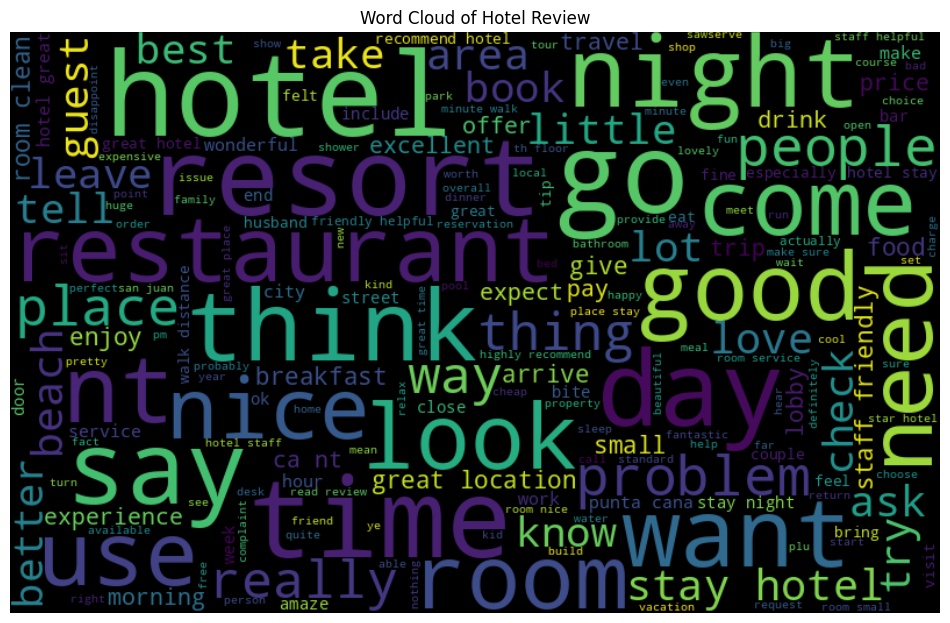

In [ ]:
# Concatenate all cleaned texts
all_words = ' '.join(df['cleaned_review'])

# Create a word cloud
wordcloud = WordCloud(width=800, height=500, random_state=42, max_font_size=100).generate(all_words)

# Display the word cloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud of Hotel Review')
plt.show()

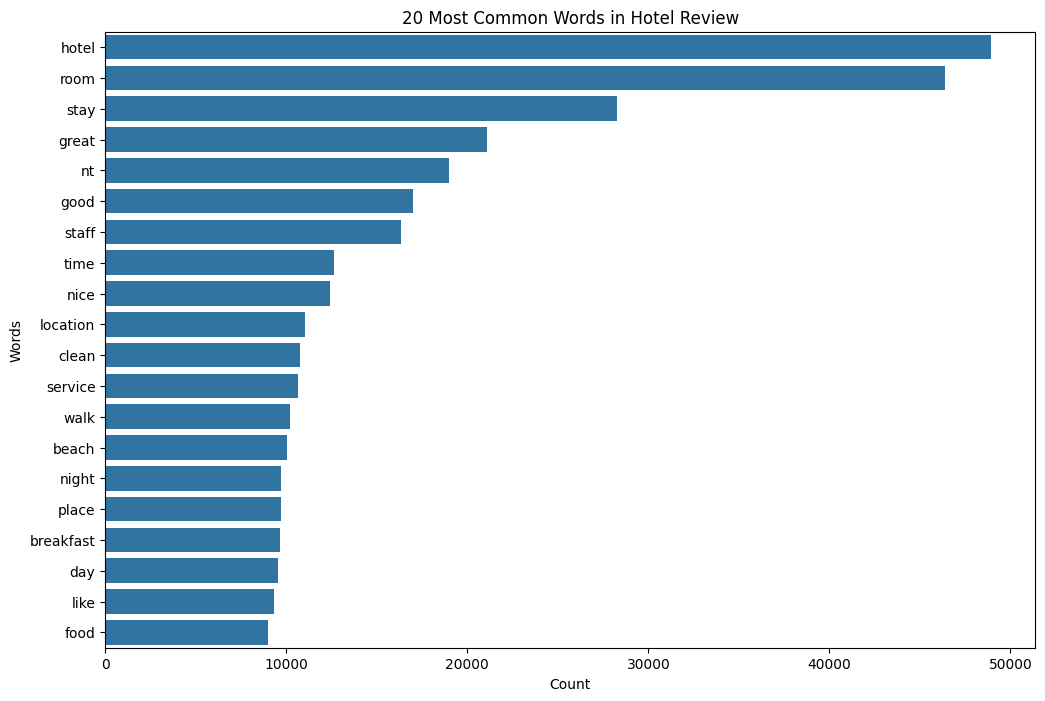

In [ ]:
# Extract most frequent words
from collections import Counter

# Collect all words from the cleaned texts
all_words_list = ' '.join(df['cleaned_review']).split()

# Count the frequencies
word_counts = Counter(all_words_list)

# Display the 20 most common words
most_common_words = word_counts.most_common(20)
words, counts = zip(*most_common_words)

# Create a bar plot of the most common words
plt.figure(figsize=(12, 8))
sns.barplot(x=list(counts), y=list(words))
plt.title('20 Most Common Words in Hotel Review')
plt.xlabel('Count')
plt.ylabel('Words')
plt.show()

# **2. Tokenization & Padding**

Now let's split the data into train and test sets, then tokenize and pad the sequences.

In [ ]:
# Target Variable Preparation
# Adjust ratings to be 0-indexed (0 to 4 instead of 1 to 5)
df['Rating_Adjusted'] = df['Rating'] - 1
num_classes = df['Rating_Adjusted'].nunique()
print(f"\nNumber of unique classes (0-indexed ratings): {num_classes}")
print("Adjusted rating distribution:\n", df['Rating_Adjusted'].value_counts().sort_index())

# Split the data into train and test sets (80% train, 20% test)
X = df['cleaned_review']
y = df['Rating_Adjusted'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: 50% of temp to val, 50% to test (0.10 / 0.20 = 0.5)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Testing set: {X_test.shape[0]} samples")



Number of unique classes (0-indexed ratings): 5
Adjusted rating distribution:
 Rating_Adjusted
0    1421
1    1793
2    2184
3    6039
4    9054
Name: count, dtype: int64
Training set: 16392 samples
Validation set shape: (2049,), (2049,)
Testing set: 2050 samples


## **Data Augmentation for Class imbalance**

In [ ]:
def synonym_replacement(words, n):
    new_words = words.copy()
    random_word_list = list(set([word for word in words if wordnet.synsets(word)]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if not synonyms:
            continue
        synonym_words = set()
        for syn in synonyms:
            for l in syn.lemmas():
                synonym = l.name().replace('_', ' ').lower()
                if synonym != random_word:
                    synonym_words.add(synonym)
        if len(synonym_words) > 0:
            synonym = random.choice(list(synonym_words))
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return new_words

def random_deletion(words, p):
    if len(words) == 1:
        return words
    new_words = []
    for word in words:
        r = random.uniform(0,1)
        if r > p:
            new_words.append(word)
    if len(new_words) == 0:
        return [random.choice(words)]
    return new_words

def random_swap(words, n):
    new_words = words.copy()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(new_words)), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

def eda(sentence, alpha_sr=0.1, alpha_rd=0.1, alpha_rs=0.1, num_aug=2):
    words = sentence.split()
    num_words = len(words)
    augmented_sentences = []
    n_sr = max(1, int(alpha_sr * num_words))
    n_rd = max(1, int(alpha_rd * num_words))
    n_rs = max(1, int(alpha_rs * num_words))
    # Synonym Replacement
    augmented_sentences.append(' '.join(synonym_replacement(words, n_sr)))
    # Random Deletion
    augmented_sentences.append(' '.join(random_deletion(words, alpha_rd)))
    # Random Swap
    augmented_sentences.append(' '.join(random_swap(words, n_rs)))
    return augmented_sentences[:num_aug]


# Define minority classes based on frequency
class_counts = np.bincount(y_train)
print("Class counts in training set:", class_counts)

# Calculate threshold to identify minority classes
# Classes with samples below this threshold will be considered minority
threshold = np.mean(class_counts)
minority_classes = np.where(class_counts < threshold)[0]
print(f"Identified minority classes: {minority_classes}")

# Set augmentation parameters - more augmentations for more imbalanced classes
class_augmentation_rates = {}
for cls in minority_classes:
    # Calculate augmentation rate inversely proportional to class frequency
    # The fewer samples, the more augmentation
    base_rate = max(class_counts) / class_counts[cls] - 1
    # Cap the augmentation rate to a reasonable number
    class_augmentation_rates[cls] = min(int(base_rate * 3), 10)

print("Augmentation rates per class:", class_augmentation_rates)

# Augment only the minority classes
data_augmented = []
labels_augmented = []

# First add all original samples
for text, label in zip(X_train, y_train):
    data_augmented.append(text)
    labels_augmented.append(label)

    # Apply augmentation only to minority classes
    if label in minority_classes:
        # Get appropriate augmentation rate for this class
        num_aug = class_augmentation_rates[label]

        # Create augmented examples
        for i, aug_text in enumerate(eda(text, num_aug=num_aug)):
            if i >= num_aug:  # Limit to specified number of augmentations
                break
            data_augmented.append(aug_text)
            labels_augmented.append(label)

X_train_aug = np.array(data_augmented)
y_train_aug = np.array(labels_augmented)

# Check class distribution after augmentation
print("Original class distribution:", np.bincount(y_train))
print("Augmented class distribution:", np.bincount(y_train_aug))

Class counts in training set: [1129 1460 1752 4787 7264]
Identified minority classes: [0 1 2]
Augmentation rates per class: {0: 10, 1: 10, 2: 9}
Original class distribution: [1129 1460 1752 4787 7264]
Augmented class distribution: [4516 5840 7008 4787 7264]


In [ ]:
# Fit tokenizer on augmented training data
max_vocab_size = 10000  # Limit vocabulary size
# Use augmented data for tokenizer fitting
tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_aug)

# Get the word index
word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)} words")
print(f"Top 10 words: {list(word_index.items())[:10]}")

# Convert text to sequences using augmented data
train_sequences = tokenizer.texts_to_sequences(X_train_aug)
X_val_seq = tokenizer.texts_to_sequences(X_val)
test_sequences = tokenizer.texts_to_sequences(X_test)

# Find a sensible sequence length (95th percentile)
seq_lengths = [len(seq) for seq in train_sequences]
max_len = int(np.percentile(seq_lengths, 95))
print(f"Max sequence length (95th percentile): {max_len}")

# Pad the sequences
X_train_pad = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

# Display shapes
print(f"Padded training data shape: {X_train_pad.shape}")
print(f"Padded validation data shape: {X_val_pad.shape}")
print(f"Padded testing data shape: {X_test_pad.shape}")

# Compute class weights using the augmented labels
y_train_final = y_train_aug  # already set in previous cell
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_final), y=y_train_final)
class_weight_dict = dict(zip(np.unique(y_train_final), class_weights))
print("Class Weights (augmented):", class_weight_dict)

Vocabulary size: 63863 words
Top 10 words: [('<OOV>', 1), ('room', 2), ('hotel', 3), ('stay', 4), ('nt', 5), ('good', 6), ('great', 7), ('staff', 8), ('time', 9), ('nice', 10)]
Max sequence length (95th percentile): 268
Padded training data shape: (29415, 268)
Padded validation data shape: (2049, 268)
Padded testing data shape: (2050, 268)
Class Weights (augmented): {0: 1.3027015057573073, 1: 1.0073630136986302, 2: 0.8394691780821918, 3: 1.2289534155003135, 4: 0.8098843612334802}


# **3. Model Building**

Now, let's create two models: a Simple RNN model and an LSTM model.

In [ ]:
# Define the embedding parameters
embedding_dim = 128
rnn_units = 64
lstm_units = 64

# Create separate callbacks for each model
def create_callbacks(model_name):
    model_checkpoint = ModelCheckpoint(
        f'best_{model_name}.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    return [model_checkpoint, early_stopping, reduce_lr]

# Use separate callbacks for each model
rnn_callbacks = create_callbacks("rnn")
lstm_callbacks = create_callbacks("lstm")
word2vec_callbacks = create_callbacks("word2vec")

# **3.1. Simple RNN Model**

**3.1.1. Building the model**

In [ ]:
# Build the Simple RNN model
rnn_model = Sequential([
    # Embedding layer without regularization
    Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_len,
              mask_zero=True, input_shape=(max_len,)),

    # First RNN layer with lighter regularization
    Bidirectional(SimpleRNN(64, return_sequences=True,
                            kernel_regularizer=l2(0.001))),

    # Lighter dropout
    Dropout(0.2),

    # Second RNN layer with minimal regularization
    SimpleRNN(units=rnn_units),

    # Moderate dropout only
    Dropout(0.3),

    # Dense layer without regularization
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output layer
    Dense(num_classes, activation='softmax')
])

# Compile the model
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
rnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 268, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 268, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 268, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,541 (5.04 MB)

 Trainable params: 1,321,541 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

**3.1.2. Training the model**

In [ ]:
# Train the RNN model
print("Training the Simple RNN model...")
rnn_history = rnn_model.fit(
    X_train_pad, y_train_final,
    epochs=10,
    validation_data=(X_val_pad, y_val),
    batch_size=32,
    callbacks=rnn_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Training the Simple RNN model...
Epoch 1/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.3006 - loss: 1.6129
Epoch 1: val_loss improved from inf to 1.23158, saving model to best_rnn.h5


920/920 ━━━━━━━━━━━━━━━━━━━━ 330s 351ms/step - accuracy: 0.3007 - loss: 1.6127 - val_accuracy: 0.4788 - val_loss: 1.2316 - learning_rate: 0.0010
Epoch 2/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.5274 - loss: 1.1006
Epoch 2: val_loss improved from 1.23158 to 1.16642, saving model to best_rnn.h5


920/920 ━━━━━━━━━━━━━━━━━━━━ 379s 348ms/step - accuracy: 0.5274 - loss: 1.1005 - val_accuracy: 0.5105 - val_loss: 1.1664 - learning_rate: 0.0010
Epoch 3/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.6533 - loss: 0.8373
Epoch 3: val_loss did not improve from 1.16642
920/920 ━━━━━━━━━━━━━━━━━━━━ 325s 351ms/step - accuracy: 0.6533 - loss: 0.8373 - val_accuracy: 0.4998 - val_loss: 1.2615 - learning_rate: 0.0010
Epoch 4/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.7113 - loss: 0.7112
Epoch 4: val_loss did not improve from 1.16642
920/920 ━━━━━━━━━━━━━━━━━━━━ 329s 357ms/step - accuracy: 0.7113 - loss: 0.7112 - val_accuracy: 0.5061 - val_loss: 1.2850 - learning_rate: 0.0010
Epoch 5/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.7505 - loss: 0.6062
Epoch 5: val_loss did not improve from 1.16642

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
920/920 ━━━━━━━━━━━━━━━━━━━━ 377s 352ms/step - accuracy: 0.7505 - loss: 0.6062 - va

**3.1.3. Plotting the model**

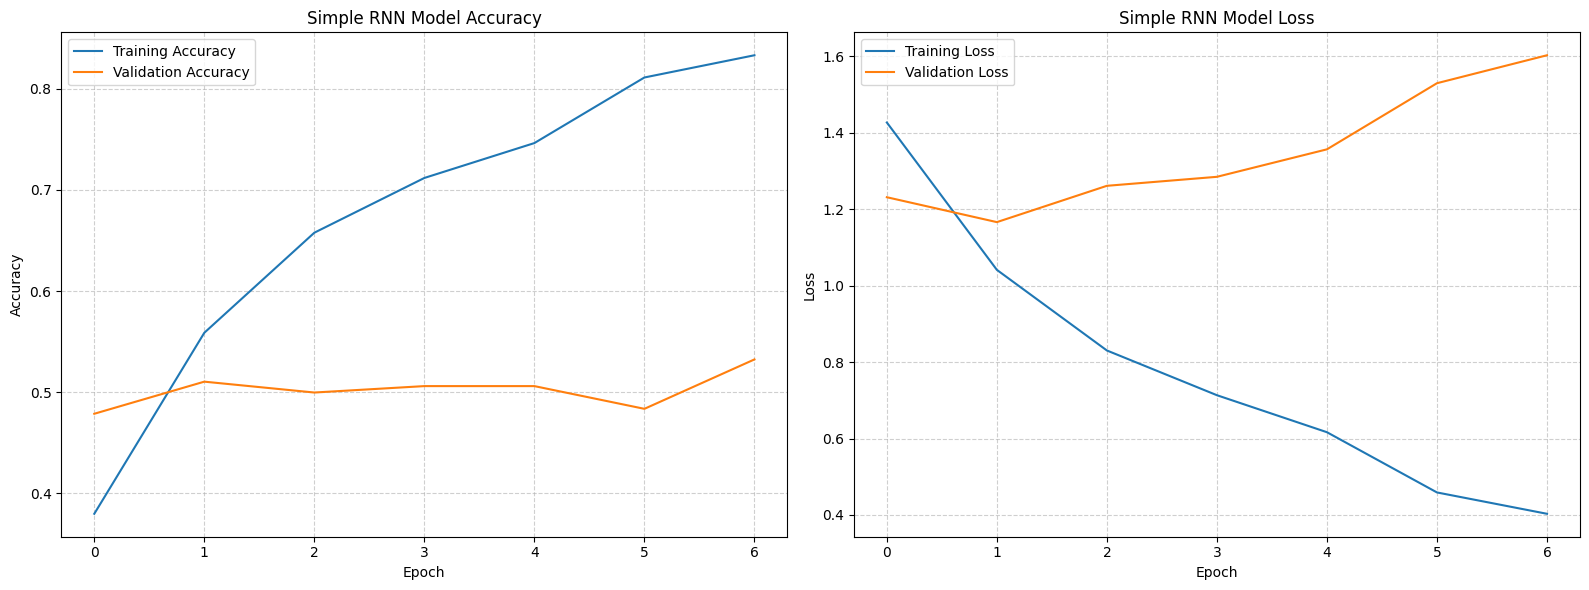

In [ ]:
# Plot training vs validation metrics for Simple RNN
plt.figure(figsize=(16, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Simple RNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['loss'], label='Training Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')
plt.title('Simple RNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**3.1.4. Evaulating the model**

65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step
===== Simple RNN Model Evaluation =====
Test Accuracy: 0.5141


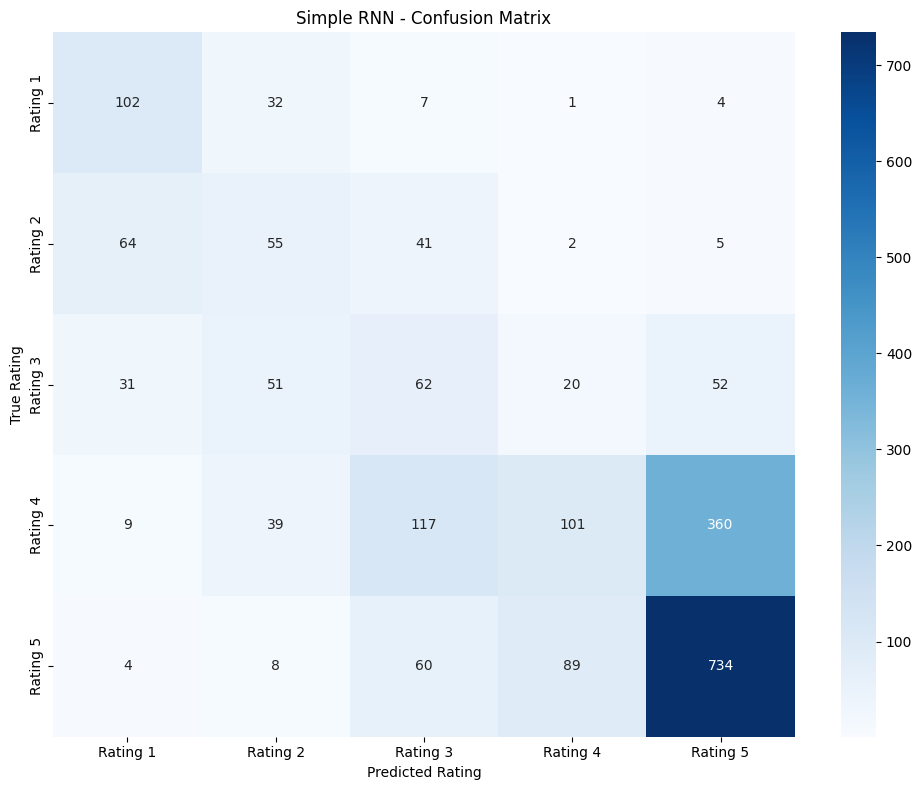


Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.49      0.70      0.57       146
    Rating 2       0.30      0.33      0.31       167
    Rating 3       0.22      0.29      0.25       216
    Rating 4       0.47      0.16      0.24       626
    Rating 5       0.64      0.82      0.72       895

    accuracy                           0.51      2050
   macro avg       0.42      0.46      0.42      2050
weighted avg       0.50      0.51      0.48      2050



In [ ]:
# Evaluate Simple RNN on test data
y_pred_rnn = np.argmax(rnn_model.predict(X_test_pad), axis=1)
rnn_accuracy = accuracy_score(y_test, y_pred_rnn)

print("===== Simple RNN Model Evaluation =====")
print(f"Test Accuracy: {rnn_accuracy:.4f}")

# Confusion Matrix for Simple RNN
plt.figure(figsize=(10, 8))
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
class_names = [f"Rating {i+1}" for i in range(5)]  # Assuming 5 rating classes

sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names)
plt.title('Simple RNN - Confusion Matrix')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.tight_layout()
plt.show()

# Classification Report for Simple RNN
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rnn, target_names=class_names))

#**3.2. LSTM Model**

**3.2.1. Building the model**

In [ ]:
# Build the LSTM model
lstm_model = Sequential([
    # Embedding layer
    Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_len,
              mask_zero=True, input_shape=(max_len,)),

    # SpatialDropout1D with light rate
    SpatialDropout1D(0.2),

    # Single LSTM layer (simplified)
    Bidirectional(LSTM(lstm_units, dropout=0.1, recurrent_dropout=0.1)),

    # Moderate dropout
    Dropout(0.2),

    # Dense layer
    Dense(64, activation='relu'),

    # Final dropout
    Dropout(0.25),

    # Output layer
    Dense(num_classes, activation='softmax')
])

# Compile the model
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 268, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 268, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,397 (5.29 MB)

 Trainable params: 1,387,397 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

**3.2.2. Training the model**

In [ ]:
# Train the LSTM model
print("Training the LSTM model...")
lstm_history = lstm_model.fit(
    X_train_pad, y_train_final,
    epochs=10,
    validation_data=(X_val_pad, y_val),
    batch_size=32,
    callbacks=lstm_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Training the LSTM model...
Epoch 1/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.4715 - loss: 1.1565
Epoch 1: val_loss improved from inf to 0.87455, saving model to best_lstm.h5


920/920 ━━━━━━━━━━━━━━━━━━━━ 722s 773ms/step - accuracy: 0.4716 - loss: 1.1562 - val_accuracy: 0.6447 - val_loss: 0.8746 - learning_rate: 0.0010
Epoch 2/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.7494 - loss: 0.6178
Epoch 2: val_loss did not improve from 0.87455
920/920 ━━━━━━━━━━━━━━━━━━━━ 749s 780ms/step - accuracy: 0.7494 - loss: 0.6177 - val_accuracy: 0.6213 - val_loss: 0.9928 - learning_rate: 0.0010
Epoch 3/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.8326 - loss: 0.4073
Epoch 3: val_loss did not improve from 0.87455
920/920 ━━━━━━━━━━━━━━━━━━━━ 744s 783ms/step - accuracy: 0.8326 - loss: 0.4073 - val_accuracy: 0.6003 - val_loss: 1.1556 - learning_rate: 0.0010
Epoch 4/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.8681 - loss: 0.3155
Epoch 4: val_loss did not improve from 0.87455

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
920/920 ━━━━━━━━━━━━━━━━━━━━ 755s 797ms/step - accuracy: 0.8681 - loss: 0.3155 - va

**3.2.3. Plotting the model**

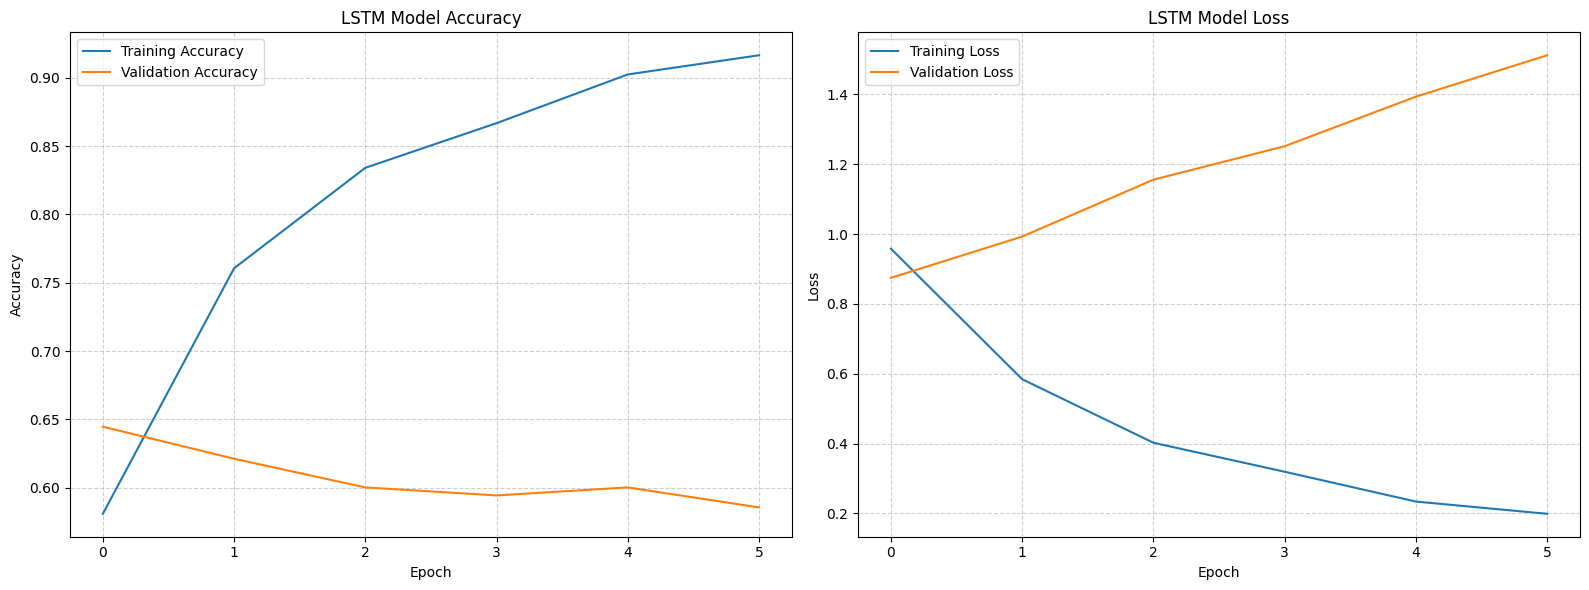

In [ ]:
# Plot training vs validation metrics for LSTM
plt.figure(figsize=(16, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='Training Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**3.2.4. Evaluating the model**

65/65 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step
===== LSTM Model Evaluation =====
Test Accuracy: 0.6385


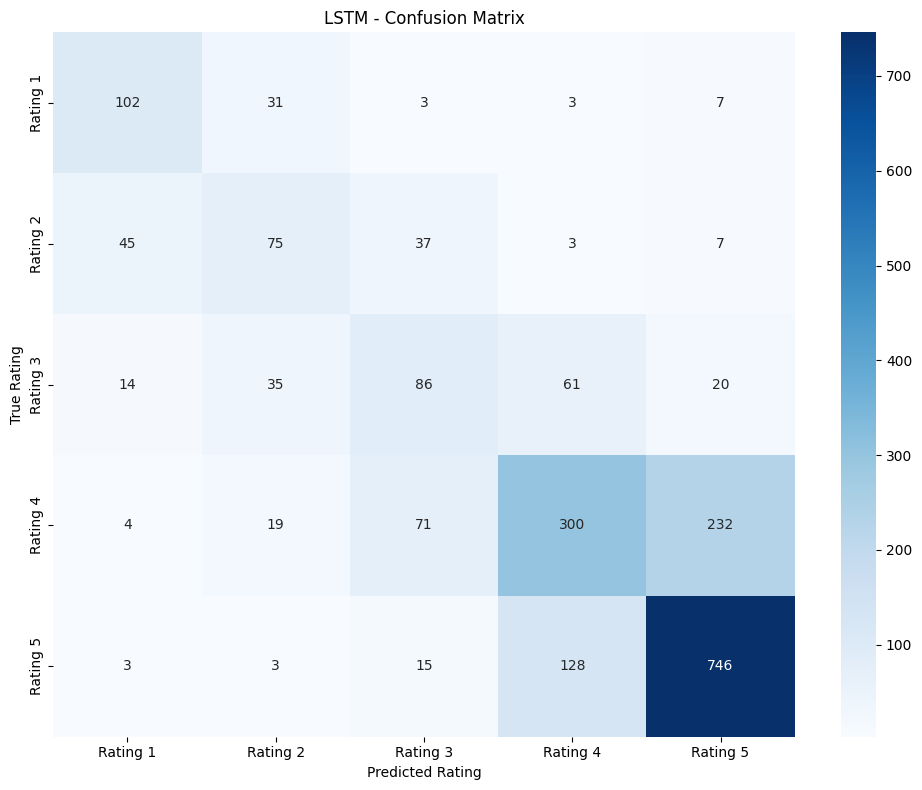


Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.61      0.70      0.65       146
    Rating 2       0.46      0.45      0.45       167
    Rating 3       0.41      0.40      0.40       216
    Rating 4       0.61      0.48      0.54       626
    Rating 5       0.74      0.83      0.78       895

    accuracy                           0.64      2050
   macro avg       0.56      0.57      0.56      2050
weighted avg       0.63      0.64      0.63      2050



In [ ]:
# Evaluate LSTM on test data
y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=1)
lstm_accuracy = accuracy_score(y_test, y_pred_lstm)

print("===== LSTM Model Evaluation =====")
print(f"Test Accuracy: {lstm_accuracy:.4f}")

# Confusion Matrix for LSTM
plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names)
plt.title('LSTM - Confusion Matrix')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.tight_layout()
plt.show()

# Classification Report for LSTM
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=class_names))

## **3.3. LSTM with pretrained Word2Vec embeddings.**

**3.3.1. Building the model**

In [ ]:
# Download and load pretrained Word2Vec embeddings
# from gensim.models import Word2Vec
from gensim.models import KeyedVectors
import os
import wget
import shutil
import gzip

# Create a directory for models if it doesn't exist
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

word2vec_path = os.path.join(models_dir, "GoogleNews-vectors-negative300.bin")

# Check if the file already exists
if os.path.exists(word2vec_path):
 print(f"Model already exists at {word2vec_path}")

else:
    print("Downloading Word2Vec model...")

    try:
        import gensim.downloader as api
        print("Downloading Word2Vec model using gensim (this may take some time)...")
        model = api.load("word2vec-google-news-300")
        print("Saving model to binary format...")
        model.save_word2vec_format(word2vec_path, binary=True)
        print(f"Model saved to {word2vec_path}")
    except Exception as e:
        print(f"Error downloading with gensim: {e}")


word2vec_model = KeyedVectors.load_word2vec_format(word2vec_path, binary=True)
print("Word2Vec model loaded successfully!")

# Create an embedding matrix from Word2Vec model
embedding_dim = 300  # Match the dimension of Word2Vec vectors

# Verify Word2Vec dimension matches expected embedding_dim
if word2vec_model.vector_size != embedding_dim:
    print(f"Warning: Word2Vec model has {word2vec_model.vector_size} dimensions, but embedding_dim is {embedding_dim}")
    embedding_dim = word2vec_model.vector_size

# Initialize the embedding matrix
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Counter for statistics
found_words = 0
missing_words = 0

# Fill the embedding matrix
for word, idx in tokenizer.word_index.items():
    try:
        if word in word2vec_model:
            embedding_matrix[idx] = word2vec_model[word]
            found_words += 1
        else:
            # Initialize missing words with small random values
            embedding_matrix[idx] = np.random.uniform(-0.25, 0.25, embedding_dim)
            missing_words += 1
    except KeyError:
        # Handle any unexpected key errors
        embedding_matrix[idx] = np.random.uniform(-0.25, 0.25, embedding_dim)
        missing_words += 1

# Calculate statistics
total_words = vocab_size - 1  # Subtract 1 for padding index
coverage = found_words / total_words * 100

print(f"Found {found_words} words in Word2Vec out of {total_words} words in vocabulary ({coverage:.2f}%)")
print(f"Randomly initialized {missing_words} words not found in Word2Vec")

# Build LSTM with Word2Vec
model_lstm_w2v = Sequential([
    # Embedding layer with pretrained weights
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False,           # Keep embeddings fixed
        input_shape=(max_len,)
    ),

    # Light SpatialDropout1D
    SpatialDropout1D(0.2),

    # LSTM layers
    Bidirectional(LSTM(lstm_units, dropout=0.1, recurrent_dropout=0.1)),

    # Light dropout
    Dropout(0.2),

    # Dense layer
    Dense(64, activation='relu'),

    # Final dropout
    Dropout(0.25),

    # Output layer
    Dense(num_classes, activation='softmax')
])


model_lstm_w2v.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=2.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_lstm_w2v.summary()


[==================================================] 100.0% 1662.8/1662.8MB downloaded
Saving model to binary format...
Model saved to models/GoogleNews-vectors-negative300.bin
Word2Vec model loaded successfully!
Found 26350 words in Word2Vec out of 63863 words in vocabulary (41.26%)
Randomly initialized 37513 words not found in Word2Vec


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 268, 300)       │    19,159,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 268, 300)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,354,661 (73.83 MB)

 Trainable params: 195,461 (763.52 KB)

 Non-trainable params: 19,159,200 (73.09 MB)

**3.3.2. Training the model**

In [ ]:
# Train the LSTM with Word2Vec model
print("Training Model 3: LSTM with Word2Vec")
history_lstm_w2v = model_lstm_w2v.fit(
    X_train_pad, y_train_final,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=word2vec_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Training Model 3: LSTM with Word2Vec
Epoch 1/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - accuracy: 0.3715 - loss: 1.3568
Epoch 1: val_loss improved from inf to 0.99278, saving model to best_word2vec.h5


920/920 ━━━━━━━━━━━━━━━━━━━━ 695s 742ms/step - accuracy: 0.3716 - loss: 1.3566 - val_accuracy: 0.5700 - val_loss: 0.9928 - learning_rate: 5.0000e-04
Epoch 2/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.5236 - loss: 1.0810
Epoch 2: val_loss improved from 0.99278 to 0.87826, saving model to best_word2vec.h5


920/920 ━━━━━━━━━━━━━━━━━━━━ 743s 744ms/step - accuracy: 0.5236 - loss: 1.0810 - val_accuracy: 0.6193 - val_loss: 0.8783 - learning_rate: 5.0000e-04
Epoch 3/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.5526 - loss: 1.0149
Epoch 3: val_loss did not improve from 0.87826
920/920 ━━━━━━━━━━━━━━━━━━━━ 689s 749ms/step - accuracy: 0.5526 - loss: 1.0148 - val_accuracy: 0.5891 - val_loss: 0.9546 - learning_rate: 5.0000e-04
Epoch 4/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.5661 - loss: 0.9839
Epoch 4: val_loss improved from 0.87826 to 0.86099, saving model to best_word2vec.h5


920/920 ━━━━━━━━━━━━━━━━━━━━ 750s 758ms/step - accuracy: 0.5661 - loss: 0.9839 - val_accuracy: 0.6301 - val_loss: 0.8610 - learning_rate: 5.0000e-04
Epoch 5/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.5848 - loss: 0.9374
Epoch 5: val_loss did not improve from 0.86099
920/920 ━━━━━━━━━━━━━━━━━━━━ 735s 750ms/step - accuracy: 0.5848 - loss: 0.9374 - val_accuracy: 0.5817 - val_loss: 0.9424 - learning_rate: 5.0000e-04
Epoch 6/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.6007 - loss: 0.9139
Epoch 6: val_loss did not improve from 0.86099
920/920 ━━━━━━━━━━━━━━━━━━━━ 742s 750ms/step - accuracy: 0.6007 - loss: 0.9139 - val_accuracy: 0.5983 - val_loss: 0.9084 - learning_rate: 5.0000e-04
Epoch 7/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.6118 - loss: 0.8776
Epoch 7: val_loss did not improve from 0.86099

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
920/920 ━━━━━━━━━━━━━━━━━━━━ 741s 749ms/step - accuracy: 0.6118 - loss:

920/920 ━━━━━━━━━━━━━━━━━━━━ 764s 773ms/step - accuracy: 0.6248 - loss: 0.8541 - val_accuracy: 0.6306 - val_loss: 0.8287 - learning_rate: 2.5000e-04
Epoch 9/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 733ms/step - accuracy: 0.6373 - loss: 0.8286
Epoch 9: val_loss did not improve from 0.82873
920/920 ━━━━━━━━━━━━━━━━━━━━ 726s 756ms/step - accuracy: 0.6373 - loss: 0.8286 - val_accuracy: 0.6291 - val_loss: 0.8406 - learning_rate: 2.5000e-04
Epoch 10/10
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.6436 - loss: 0.8124
Epoch 10: val_loss improved from 0.82873 to 0.82121, saving model to best_word2vec.h5


920/920 ━━━━━━━━━━━━━━━━━━━━ 702s 763ms/step - accuracy: 0.6436 - loss: 0.8124 - val_accuracy: 0.6398 - val_loss: 0.8212 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 10.


**3.3.3. Plotting the model**

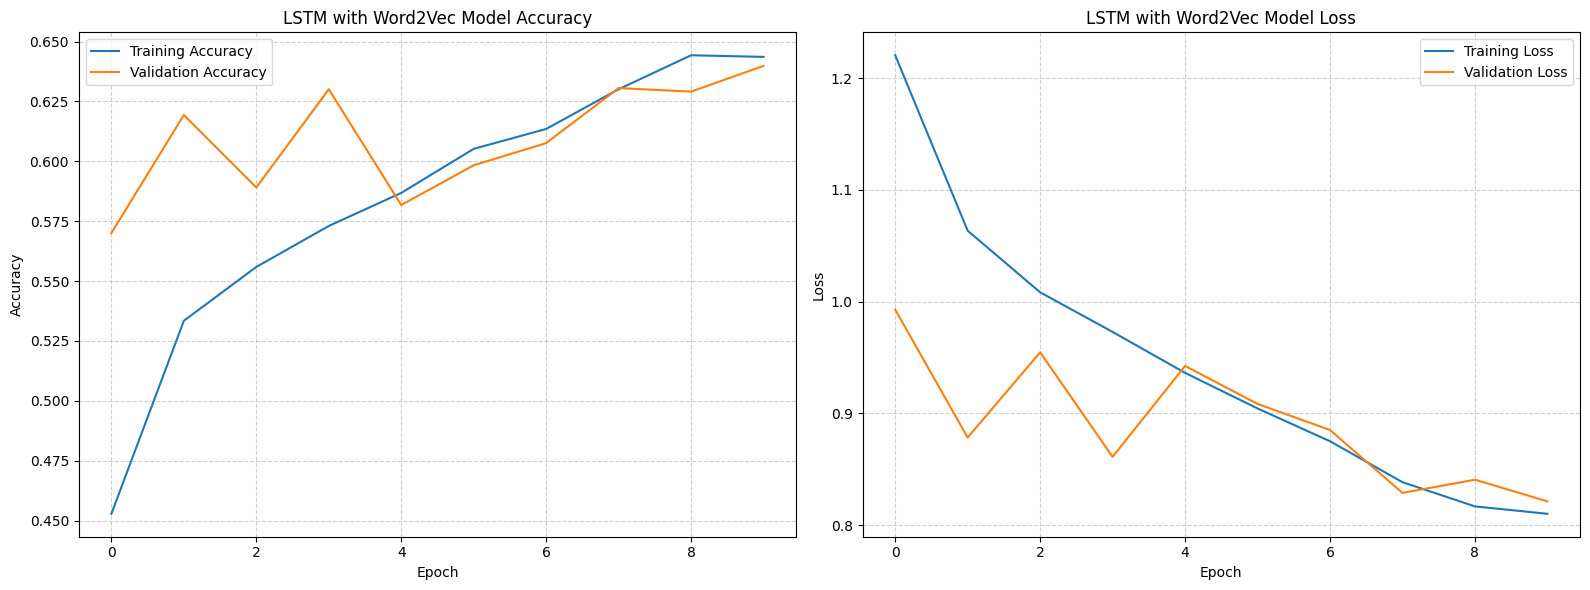

In [ ]:
# Plot training vs validation metrics for LSTM with Word2Vec
plt.figure(figsize=(16, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_lstm_w2v.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm_w2v.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM with Word2Vec Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history_lstm_w2v.history['loss'], label='Training Loss')
plt.plot(history_lstm_w2v.history['val_loss'], label='Validation Loss')
plt.title('LSTM with Word2Vec Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**3.3.4. Evaluating the model**

65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step
===== LSTM with Word2Vec Model Evaluation =====
Test Accuracy: 0.6463


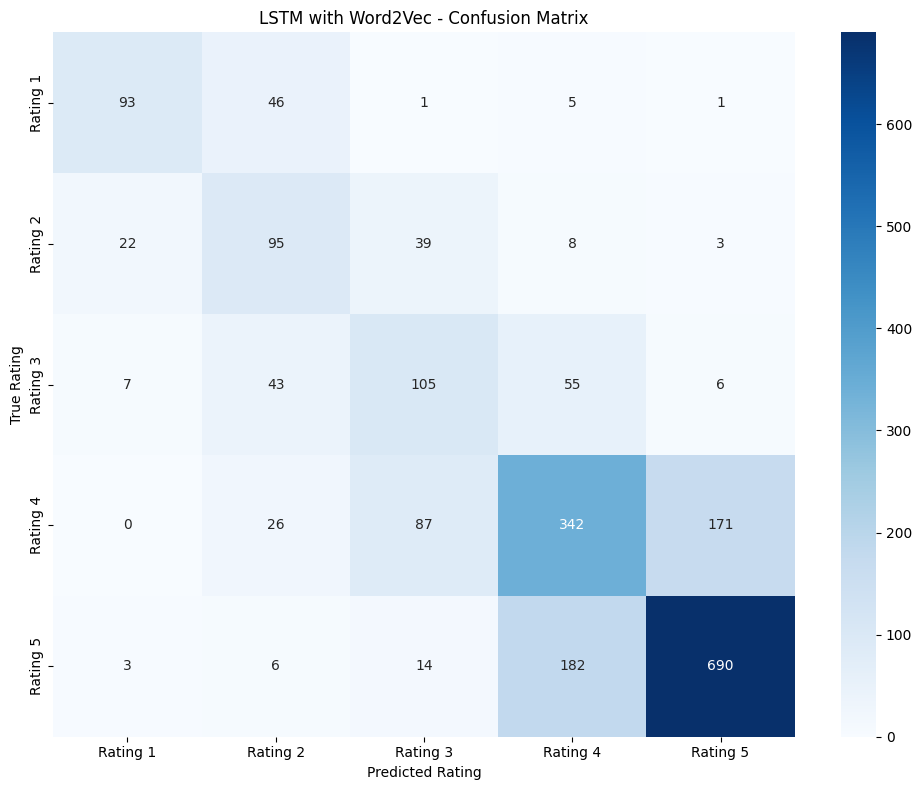


Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.74      0.64      0.69       146
    Rating 2       0.44      0.57      0.50       167
    Rating 3       0.43      0.49      0.45       216
    Rating 4       0.58      0.55      0.56       626
    Rating 5       0.79      0.77      0.78       895

    accuracy                           0.65      2050
   macro avg       0.60      0.60      0.60      2050
weighted avg       0.66      0.65      0.65      2050



In [ ]:
# Evaluate LSTM with Word2Vec on test data
y_pred_w2v = np.argmax(model_lstm_w2v.predict(X_test_pad), axis=1)
lstm_w2v_accuracy = accuracy_score(y_test, y_pred_w2v)

print("===== LSTM with Word2Vec Model Evaluation =====")
print(f"Test Accuracy: {lstm_w2v_accuracy:.4f}")

# Confusion Matrix for LSTM with Word2Vec
plt.figure(figsize=(10, 8))
cm_w2v = confusion_matrix(y_test, y_pred_w2v)

sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names)
plt.title('LSTM with Word2Vec - Confusion Matrix')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.tight_layout()
plt.show()

# Classification Report for LSTM with Word2Vec
print("\nClassification Report:")
print(classification_report(y_test, y_pred_w2v, target_names=class_names))

## **4. Model Test Accuracy Comparison**

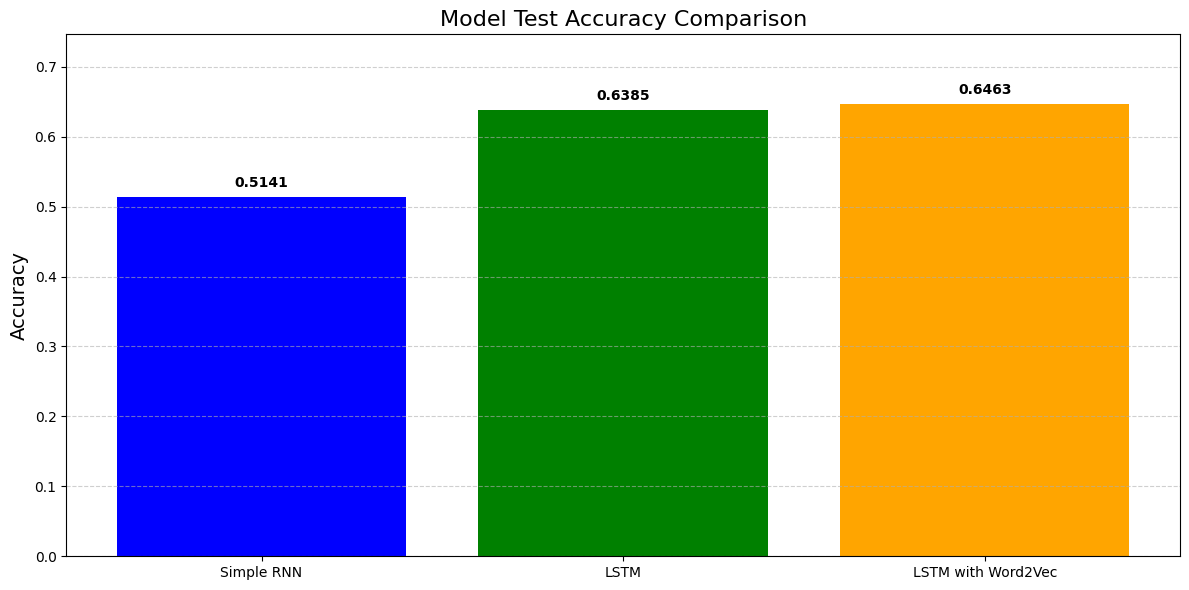

The best performing model is: LSTM with Word2Vec with test accuracy: 0.6463
Best model saved as 'best_model_for_gui.h5' for use in the GUI


In [ ]:
# Compare test accuracy for all models
plt.figure(figsize=(12, 6))

# Collect test accuracies
models = ['Simple RNN', 'LSTM', 'LSTM with Word2Vec']
test_accuracies = [rnn_accuracy, lstm_accuracy, lstm_w2v_accuracy]

# Plot test accuracies
bars = plt.bar(models, test_accuracies, color=['blue', 'green', 'orange'])

# Add accuracy values on bars
for bar, acc in zip(bars, test_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Model Test Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, max(test_accuracies) + 0.1)  # Add some space for text
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Print the best model
best_model_idx = np.argmax(test_accuracies)
print(f"The best performing model is: {models[best_model_idx]} with test accuracy: {test_accuracies[best_model_idx]:.4f}")

# Save information about the best model
best_model_paths = ['best_rnn.h5', 'best_lstm.h5', 'best_word2vec.h5']
with open('best_model_info.txt', 'w') as f:
    f.write(f"Best model: {models[best_model_idx]}\n")
    f.write(f"Model path: {best_model_paths[best_model_idx]}\n")
    f.write(f"Test accuracy: {test_accuracies[best_model_idx]:.4f}\n")

# Save the best model for GUI
if best_model_idx == 0:
    best_model = rnn_model
elif best_model_idx == 1:
    best_model = lstm_model
else:
    best_model = model_lstm_w2v

best_model.save('best_model_for_gui.h5')
print(f"Best model saved as 'best_model_for_gui.h5' for use in the GUI")

## **6. GUI for Real-Time Prediction**

*   Creating a simple interface using Gradio for real-time predictions.



In [ ]:
# Install gradio if not already installed
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.4 MB/s eta 0:00:00


In [ ]:
import gradio as gr
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pickle

# Load the saved best model
best_model = load_model('best_model_for_gui.h5')

# Set configuration parameters
max_len = max_len
num_classes = num_classes
CLASS_LABELS = [f"Rating {i+1}" for i in range(num_classes)]

def predict_sentiment(review):
    """
    Function to predict the sentiment of a given review using the best model.
    """
    # Clean the review
    cleaned_review = text_cleaning_pipeline(review)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_review])
    padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

    # Get prediction using best model
    prediction_probs = best_model.predict(padded_sequence)[0]

    # Create a dictionary of labels and their probabilities
    confidences = {CLASS_LABELS[i]: float(prediction_probs[i]) for i in range(num_classes)}

    return confidences

# Create the Gradio interface
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Enter a hotel review here..."),
    outputs=gr.Label(num_top_classes=num_classes, label="Predicted Rating Probabilities"),
    title="Hotel Review Rating Predictor",
    description="Enter a review text to predict its star rating (1-5). This model uses advanced deep learning to analyze hotel reviews.",
    examples=[
        ["The room was absolutely wonderful, spacious with a comfortable bed. The staff was exceptionally friendly and the breakfast buffet was superb. I would definitely stay here again!"],
        ["It was a terrible experience. The room was dirty, the staff was rude, and the breakfast was cold. Would never come back."],
        ["The hotel was okay, nothing too special but clean enough. Decent location and reasonable price. Breakfast was standard."],
        ["Great location with beautiful views of the city. The staff was professional but the room was a bit small. Nice amenities overall."],
        ["The bathroom was not thoroughly cleaned and had hairs all over. The mattress was uncomfortable and the walls were thin. I could hear everything in the next room."]
    ],
    theme=gr.themes.Soft() #theme

)

# Launch the interface
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://beef65480ef76d5b0e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
